# Example of running and analysing the energy system model of the NL

In [1253]:
import calliope
import pandas as pd

calliope.set_log_verbosity("INFO", include_solver_output=True)

# 1. Reference case
## 1.1. Create and solve the model

In [1254]:
model = calliope.read_yaml('C:\\Users\\amran\\Downloads\\SEN1531_Integrated_Energy_sys\\SEN1531_Integrated_Energy_sys\\calliope_integrated\\model_starter_toolkit\\calliope_model\\model\\model.yaml')


[2026-03-19 13:06:57] INFO     Math init | loading pre-defined math.
[2026-03-19 13:06:57] INFO     Math init | loading math files {'milp', 'storage_inter_cluster', 'spores', 'base', 'operate'}.
[2026-03-19 13:06:57] INFO     Model: preprocessing data
[2026-03-19 13:06:57] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-19 13:06:58] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:06:58] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:06:58] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:06:58] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:06:58] INFO     Model: initialisation complete


## check of the capacity factors: Visualized

Reading: C:\Users\amran\Downloads\SEN1531_Integrated_Energy_sys\SEN1531_Integrated_Energy_sys\calliope_integrated\model_starter_toolkit\calliope_model\model\input_data_tables\cf_avg_real.csv
Exists? True
Data shape: (8760, 2)

Column names: ['datetime', 'capacity_factor']
Using datetime column: datetime
Using capacity factor column: capacity_factor


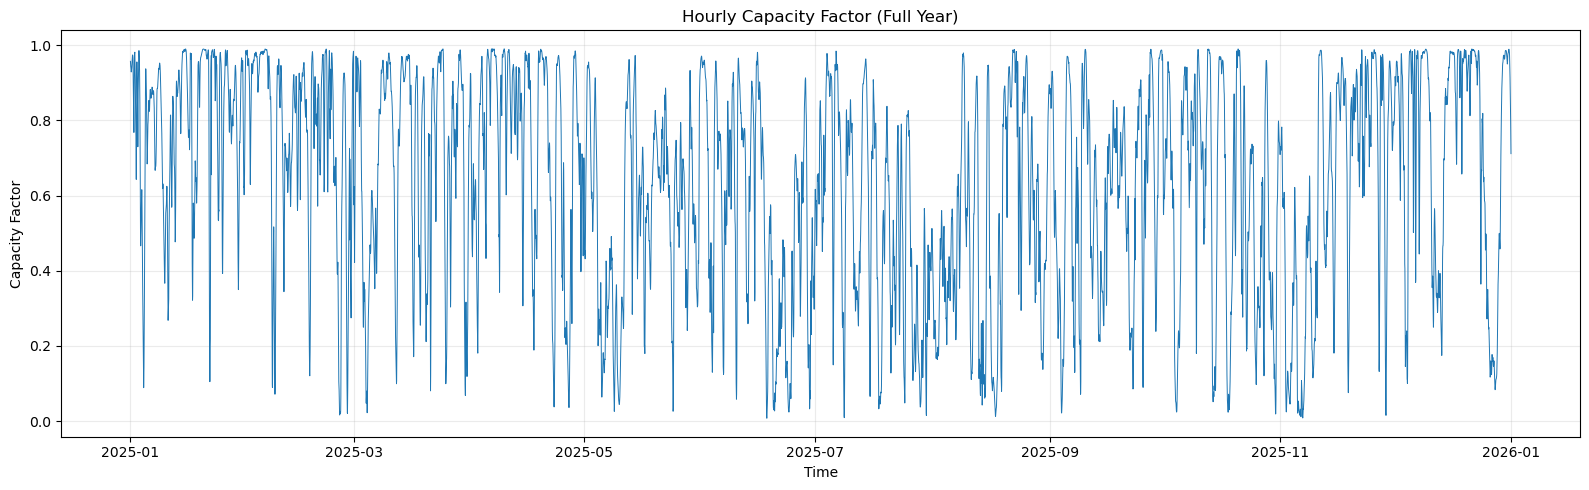

In [1255]:
#make a plot of the renewables data against its time steps and the capacity factor for the whole year 
import os
import matplotlib.pyplot as plt
from pathlib import Path

# Ensure we're in the correct model folder so relative paths work
model_dir = Path(r"C:\Users\amran\Downloads\SEN1531_Integrated_Energy_sys\SEN1531_Integrated_Energy_sys\calliope_integrated\model_starter_toolkit\calliope_model")
os.chdir(model_dir)

renewables_path = model_dir / "model" / "input_data_tables" / "cf_avg_real.csv"
print("Reading:", renewables_path)
print("Exists?", renewables_path.exists())

# Load renewables data
renewables_data = pd.read_csv(renewables_path, skiprows=2, names=['datetime', 'capacity_factor'])

# Display data info
print("Data shape:", renewables_data.shape)
print("\nColumn names:", renewables_data.columns.tolist())

# Convert datetime column
renewables_data['datetime'] = pd.to_datetime(renewables_data['datetime'], format='%Y-%m-%d %H:%M:%S')

# Use the capacity_factor column
dt_col = 'datetime'
cf_col = 'capacity_factor'

print(f"Using datetime column: {dt_col}")
print(f"Using capacity factor column: {cf_col}")

# Create the plot: x is datetime over the full year, y is capacity factor
plt.figure(figsize=(16, 5))
plt.plot(renewables_data[dt_col], renewables_data[cf_col], linewidth=0.7)
plt.xlabel('Time')
plt.ylabel('Capacity Factor')
plt.title('Hourly Capacity Factor (Full Year)')
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

Reading: C:\Users\amran\Downloads\SEN1531_Integrated_Energy_sys\SEN1531_Integrated_Energy_sys\calliope_integrated\model_starter_toolkit\calliope_model\model\input_data_tables\renewables11.csv
Exists? True
Data shape: (8760, 2)

Column names: ['datetime', 'capacity_factor']
Using datetime column: datetime
Using capacity factor column: capacity_factor


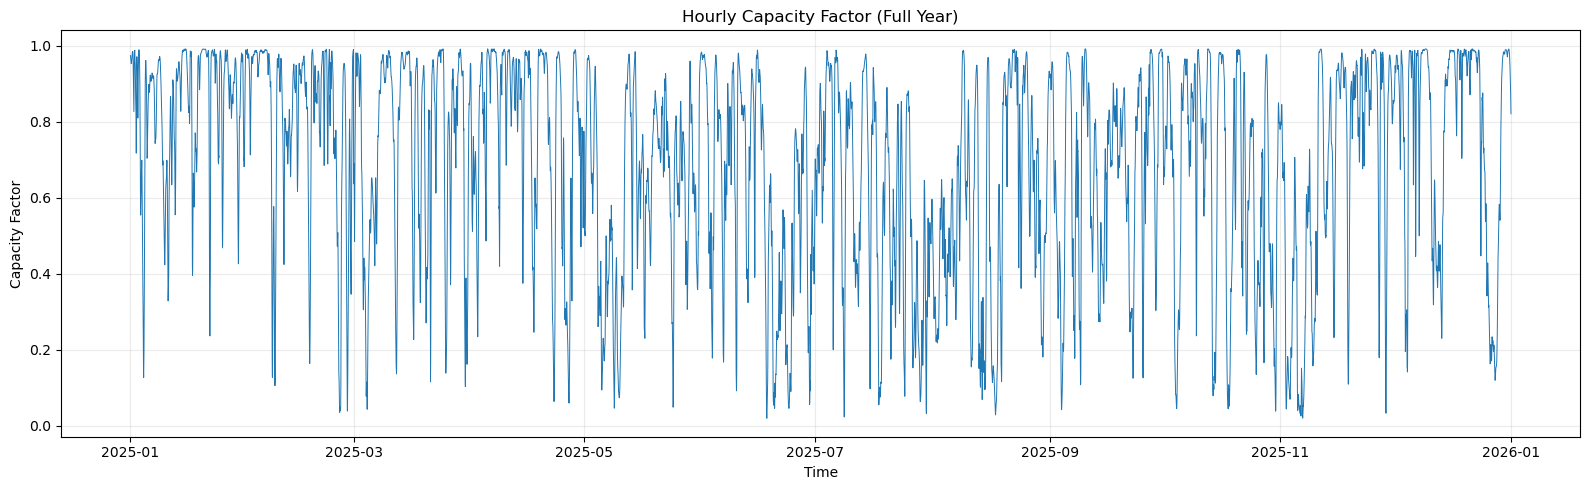

In [1256]:
#make a plot of the renewables data against its time steps and the capacity factor for the whole year 
import os
import matplotlib.pyplot as plt
from pathlib import Path

# Ensure we're in the correct model folder so relative paths work
model_dir = Path(r"C:\Users\amran\Downloads\SEN1531_Integrated_Energy_sys\SEN1531_Integrated_Energy_sys\calliope_integrated\model_starter_toolkit\calliope_model")
os.chdir(model_dir)

renewables_path = model_dir / "model" / "input_data_tables" / "renewables11.csv"
print("Reading:", renewables_path)
print("Exists?", renewables_path.exists())

# Load renewables data
renewables_data = pd.read_csv(renewables_path, skiprows=2, names=['datetime', 'capacity_factor'])

# Display data info
print("Data shape:", renewables_data.shape)
print("\nColumn names:", renewables_data.columns.tolist())

# Convert datetime column
renewables_data['datetime'] = pd.to_datetime(renewables_data['datetime'], format='%Y-%m-%d %H:%M:%S')

# Use the capacity_factor column
dt_col = 'datetime'
cf_col = 'capacity_factor'

print(f"Using datetime column: {dt_col}")
print(f"Using capacity factor column: {cf_col}")

# Create the plot: x is datetime over the full year, y is capacity factor
plt.figure(figsize=(16, 5))
plt.plot(renewables_data[dt_col], renewables_data[cf_col], linewidth=0.7)
plt.xlabel('Time')
plt.ylabel('Capacity Factor')
plt.title('Hourly Capacity Factor (Full Year)')
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [1257]:
# Check the sink_use_equals parameter, it shows the non-empty fixed-demand values used by the model.
model.inputs.sink_use_equals.to_series().dropna()

timesteps            nodes  techs       
2025-05-01 00:00:00  NLD    demand_power   18,310.83
2025-05-01 01:00:00  NLD    demand_power   17,959.40
2025-05-01 02:00:00  NLD    demand_power   17,552.16
2025-05-01 03:00:00  NLD    demand_power   17,412.56
2025-05-01 04:00:00  NLD    demand_power   17,839.96
                                              ...   
2025-05-30 19:00:00  NLD    demand_power   22,702.31
2025-05-30 20:00:00  NLD    demand_power   20,832.62
2025-05-30 21:00:00  NLD    demand_power   19,581.94
2025-05-30 22:00:00  NLD    demand_power   19,311.75
2025-05-30 23:00:00  NLD    demand_power   18,532.52
Name: sink_use_equals, Length: 720, dtype: float64

In [1258]:
import os, calliope
os.chdir(r"C:\Users\amran\Downloads\SEN1531_Integrated_Energy_sys\SEN1531_Integrated_Energy_sys\calliope_integrated\model_starter_toolkit\calliope_model")
model = calliope.read_yaml("model/model.yaml")
model.build()
model.solve()


print(model.results.attrs.get("termination_condition"))  # should be optimal/feasible
model.to_netcdf("results/default_results.nc")


[2026-03-19 13:06:59] INFO     Math init | loading pre-defined math.
[2026-03-19 13:06:59] INFO     Math init | loading math files {'milp', 'storage_inter_cluster', 'spores', 'base', 'operate'}.
[2026-03-19 13:06:59] INFO     Model: preprocessing data
[2026-03-19 13:06:59] INFO     Math build | building applied math with ['base', 'operate'].


[2026-03-19 13:06:59] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:06:59] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:06:59] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:06:59] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:06:59] INFO     Model: initialisation complete
[2026-03-19 13:06:59] INFO     Model: backend build starting
[2026-03-19 13:07:00] INFO     Optimisation Model | parameters/lookups | Generated.
[2026-03-19 13:07:00] INFO     Optimisation Model | variables | Generated.
[2026-03-19 13:07:01] INFO     Optimisation Model | global_expressions | Generated.
[2026-03-19 13:07:04] INFO     Optimisation Model | constraints | Generated.
[2026-03-19 13:07:04] INFO     Opti

## 1.2. Do a first sense-check of the results

In [1259]:
# Shadow price for the power system balance constraint
balance_price = model.backend.shadow_prices.get("system_balance").to_series().reset_index()
balance_price.head()

,nodes,carriers,timesteps,system_balance
0,NLD,hydrogen,2025-05-01 00:00:00,-0.00
1,NLD,hydrogen,2025-05-01 01:00:00,-0.00
2,NLD,hydrogen,2025-05-01 02:00:00,-0.00
3,NLD,hydrogen,2025-05-01 03:00:00,-0.00
4,NLD,hydrogen,2025-05-01 04:00:00,-0.00


In [1260]:
# # Create a Date Range to select a few days in November to inspect visually
# days_of_interest = pd.date_range('2025-01-01','2025-03-31',freq='h') 
# # Plot the days of interest
# balance_price['system_balance'].loc[balance_price['timesteps'].isin(days_of_interest)].plot()

In [1261]:
variable_costs = model.results.cost_operation_variable.to_series().dropna()
variable_costs.head()

nodes  techs            costs     timesteps          
NLD    battery_storage  monetary  2025-05-01 00:00:00   0.00
                                  2025-05-01 01:00:00   0.00
                                  2025-05-01 02:00:00   0.00
                                  2025-05-01 03:00:00   0.00
                                  2025-05-01 04:00:00   0.00
Name: cost_operation_variable, dtype: float64

In [1262]:
generation = model.results.flow_out.to_series().dropna()
generation.head()

nodes  techs            carriers  timesteps          
NLD    battery_storage  power     2025-05-01 00:00:00   0.00
                                  2025-05-01 01:00:00   0.00
                                  2025-05-01 02:00:00   0.00
                                  2025-05-01 03:00:00   0.00
                                  2025-05-01 04:00:00   0.00
Name: flow_out, dtype: float64

In [1263]:
# If we calculate the marginal generation costs per generator type,
# we should see an equivalence between the shadow price in any given
# hour and the marginal cost of the marginal generator in the merit order
marginal_generation_costs = variable_costs/generation
marginal_generation_costs.head()

nodes  techs            costs     timesteps            carriers
NLD    battery_storage  monetary  2025-05-01 00:00:00  power      NaN
                                  2025-05-01 01:00:00  power      NaN
                                  2025-05-01 02:00:00  power      NaN
                                  2025-05-01 03:00:00  power      NaN
                                  2025-05-01 04:00:00  power      NaN
dtype: float64

In [1264]:
# # To check the merit order, we may look at a particular timestep
# # and at the list of generators producing in that timestep in ascending cost order.
# # The per-timestep selection is easier done before transforming to a Pandas series.
# marginal_generation_costs_xr = model.results.cost_operation_variable / model.results.flow_out
# # We select a specific hour of the year
# my_timestep = '2025-02-23 04:00:00'
# # And we select only generators, excluding curtailment and other techs
# gen_techs = ['wind_offshore']
# # gen_techs = ['solar_pv' ,'wind_offshore', 'wind_onshore', 'ccgt', 'nuclear'] 
# # We can now inspect the marginal generation cost in that timestep
# marginal_generation_cost_in_timestep = marginal_generation_costs_xr.sel(timesteps=my_timestep, carriers='power', costs='monetary', techs=gen_techs)
# marginal_generation_cost_in_timestep.to_series().fillna(0).sort_values()

## 1.3. Export the results for further analysis at any later moment

In [1265]:
# It is helpful to store the model results as a whole in NetCDF format, which Calliope can import back
# at any later time. 
model.to_netcdf('results/default_results.nc')


## 1.4. Produce some visualisations

In this example, we provide some pre-made plotting functionalities in the 'plotting_utilities.py' file, which you can import and apply as well as use as an example for making your own custom plots.

In [1266]:
# Import some pre-made plotting functionalities as an example. You can use these, make your own, or simply
# create plots with your favourite Python library or non-Python tool, such as Excel
from plotting_utilities import plot_dispatch,plot_load_duration_curve

In [1267]:
# Dispatch plots can be generated directly from the saved model results
plot_dispatch(model_path='results/default_results.nc', plot_export_path='results/default_dispatch.html')

[2026-03-19 13:07:08] INFO     Model: preprocessing data (reentry)
[2026-03-19 13:07:08] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-19 13:07:08] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:08] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:08] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:08] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:08] INFO     Model: initialisation complete


In [1268]:
# For generating load duration curves (LDCs), instead, we first need to import back the model results,
# then extract the time-varing variable of interest
model = calliope.read_netcdf('results/default_results.nc')

[2026-03-19 13:07:08] INFO     Model: preprocessing data (reentry)
[2026-03-19 13:07:08] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-19 13:07:08] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:08] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:09] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:09] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:09] INFO     Model: initialisation complete


In [1269]:
import pandas as pd

print("Termination:", model.results.attrs.get("termination_condition"))

# Energy totals (MWh over model horizon)
demand_served = model.results.flow_in.sel(techs="demand_power", carriers="power").sum().item()
curtailed = model.results.flow_in.sel(techs="curtailment", carriers="power").sum().item()
load_shed = model.results.flow_out.sel(techs="load_shedding", carriers="power").sum().item()
wind_gen = model.results.flow_out.sel(techs="wind_offshore", carriers="power").sum().item()

# Available wind energy from profile * installed cap
wind_avail = (
    model.inputs.source_use_equals.sel(techs="wind_offshore", nodes="NLD")
    * model.inputs.flow_cap.sel(techs="wind_offshore", nodes="NLD")
).sum().item()

curtailment_rate = (curtailed / wind_avail * 100) if wind_avail > 0 else 0

# Shadow price stats


sp = model.results.shadow_price_system_balance.to_series()
price_stats = sp.describe(percentiles=[0.5, 0.95])[["mean", "50%", "95%", "max"]]

kpis = pd.Series({
    "Demand served (MWh)": demand_served,
    "Wind available (MWh)": wind_avail,
    "Wind generated (MWh)": wind_gen,
    "Curtailment (MWh)": curtailed,
    "Curtailment rate (%)": curtailment_rate,
    "Load shedding (MWh)": load_shed,
})

print(kpis)
print("\nSystem balance price stats:")
print(price_stats)



Termination: None
Demand served (MWh)    24,675,509.20
Wind available (MWh)   27,402,921.00
Wind generated (MWh)   27,402,921.00
Curtailment (MWh)       7,532,934.29
Curtailment rate (%)           27.49
Load shedding (MWh)     4,805,522.49
dtype: float64

System balance price stats:
mean   0.05
50%    0.00
95%    0.25
max    0.25
Name: shadow_price_system_balance, dtype: float64


## 2. Battery Scenario

Run only the battery pathway scenario and extract baseline + battery-specific KPIs.

In [1270]:
scenario_name = "surplus_to_battery"
model_battery = calliope.read_yaml("model/model.yaml", scenario=scenario_name)
model_battery.build()
model_battery.solve()
print("Termination:", model_battery.results.attrs.get("termination_condition"))
model_battery.to_netcdf(f"results/{scenario_name}_results.nc")


[2026-03-19 13:07:09] INFO     Loading overrides from scenario: surplus_to_battery 
[2026-03-19 13:07:09] INFO     (scenarios, surplus_to_battery ) | Applying the following overrides: ['enable_battery_pathway'].


[2026-03-19 13:07:09] INFO     Math init | loading pre-defined math.
[2026-03-19 13:07:09] INFO     Math init | loading math files {'milp', 'storage_inter_cluster', 'spores', 'base', 'operate'}.
[2026-03-19 13:07:09] INFO     Model: preprocessing data
[2026-03-19 13:07:09] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-19 13:07:09] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:09] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:10] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:10] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:10] INFO     Model: initialisation complete
[2026-03-19 13:07:10] INFO     Model: backend build starting
[2026-03-19

In [1271]:
plot_dispatch(
    model_path=f"results/{scenario_name}_results.nc",
    plot_export_path=f"results/{scenario_name}_dispatch.html",
)


[2026-03-19 13:07:16] INFO     Model: preprocessing data (reentry)
[2026-03-19 13:07:16] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-19 13:07:16] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:16] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:17] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:17] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:17] INFO     Model: initialisation complete


In [1272]:
import pandas as pd

m = calliope.read_netcdf(f"results/{scenario_name}_results.nc")

# Common KPIs
demand_served = m.results.flow_in.sel(techs="demand_power", carriers="power").sum().item()
curtailed = m.results.flow_in.sel(techs="curtailment", carriers="power").sum().item()
load_shed = m.results.flow_out.sel(techs="load_shedding", carriers="power").sum().item()
wind_gen = m.results.flow_out.sel(techs="wind_offshore", carriers="power").sum().item()

if "source_use_equals" in m.inputs.data_vars:
    wind_avail = (
        m.inputs.source_use_equals.sel(techs="wind_offshore", nodes="NLD")
        * m.inputs.flow_cap.sel(techs="wind_offshore", nodes="NLD")
    ).sum().item()
else:
    wind_avail = (
        m.inputs.source_use_max.sel(techs="wind_offshore", nodes="NLD")
        * m.inputs.flow_cap.sel(techs="wind_offshore", nodes="NLD")
    ).sum().item()

curtailment_rate = (curtailed / wind_avail * 100) if wind_avail > 0 else 0
sp = m.results.shadow_price_system_balance.sel(nodes="NLD", carriers="power").to_series().dropna()
price_stats = sp.describe(percentiles=[0.5, 0.95])[["mean", "50%", "95%", "max"]]
pd.set_option("display.float_format", "{:,.2f}".format)

# Battery-specific KPIs
battery_charge = m.results.flow_in.sel(techs="battery_storage", carriers="power").sum().item()
battery_discharge = m.results.flow_out.sel(techs="battery_storage", carriers="power").sum().item()
battery_losses = battery_charge - battery_discharge
battery_round_trip = (battery_discharge / battery_charge * 100) if battery_charge > 0 else 0

kpis_battery = pd.Series({
    "Demand served (MWh)": demand_served,
    "Wind available (MWh)": wind_avail,
    "Wind generated (MWh)": wind_gen,
    "Curtailment (MWh)": curtailed,
    "Curtailment rate (%)": curtailment_rate,
    "Load shedding (MWh)": load_shed,
    "Battery charge (MWh)": battery_charge,
    "Battery discharge (MWh)": battery_discharge,
    "Battery losses (MWh)": battery_losses,
    "Battery round-trip (%)": battery_round_trip,
})

print(kpis_battery)
print("\nPower system balance price stats:")
print(price_stats)


[2026-03-19 13:07:17] INFO     Model: preprocessing data (reentry)
[2026-03-19 13:07:17] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-19 13:07:17] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:17] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:18] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:18] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:18] INFO     Model: initialisation complete
Demand served (MWh)       24,675,509.20
Wind available (MWh)      27,402,921.00
Wind generated (MWh)      27,402,921.00
Curtailment (MWh)          5,038,054.76
Curtailment rate (%)              18.39
Load shedding (MWh)        3,547,466.84
Battery charge (M

## 3. Hydrogen Scenario

Run the hydrogen pathway scenario, export results, and compute hydrogen-specific KPIs.

In [1292]:
scenario_name_h2 = "surplus_to_hydrogen"
model_h2 = calliope.read_yaml("model/model.yaml", scenario=scenario_name_h2)
model_h2.build()
model_h2.solve()
print("Termination:", model_h2.results.attrs.get("termination_condition"))
model_h2.to_netcdf(f"results/{scenario_name_h2}_results.nc")


[2026-03-19 13:53:15] INFO     Loading overrides from scenario: surplus_to_hydrogen 
[2026-03-19 13:53:15] INFO     (scenarios, surplus_to_hydrogen ) | Applying the following overrides: ['enable_hydrogen_pathway'].
[2026-03-19 13:53:15] INFO     Math init | loading pre-defined math.


[2026-03-19 13:53:15] INFO     Math init | loading math files {'milp', 'storage_inter_cluster', 'spores', 'base', 'operate'}.
[2026-03-19 13:53:15] INFO     Model: preprocessing data
[2026-03-19 13:53:15] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-19 13:53:16] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:53:16] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:53:16] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:53:16] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:53:16] INFO     Model: initialisation complete
[2026-03-19 13:53:16] INFO     Model: backend build starting
[2026-03-19 13:53:16] INFO     Optimisation Model | parameters/lookups | Generat

In [1293]:
plot_dispatch(
    model_path=f"results/{scenario_name_h2}_results.nc",
    plot_export_path=f"results/{scenario_name_h2}_dispatch.html",
)


[2026-03-19 13:53:24] INFO     Model: preprocessing data (reentry)
[2026-03-19 13:53:24] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-19 13:53:24] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:53:24] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:53:24] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:53:24] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:53:24] INFO     Model: initialisation complete


In [1294]:
m_h2 = calliope.read_netcdf(f"results/{scenario_name_h2}_results.nc")

demand_served_h2 = m_h2.results.flow_in.sel(techs="demand_power", carriers="power").sum().item()
curtailed_h2 = m_h2.results.flow_in.sel(techs="curtailment", carriers="power").sum().item()
load_shed_h2 = m_h2.results.flow_out.sel(techs="load_shedding", carriers="power").sum().item()
wind_gen_h2 = m_h2.results.flow_out.sel(techs="wind_offshore", carriers="power").sum().item()

if "source_use_equals" in m_h2.inputs.data_vars:
    wind_avail_h2 = (m_h2.inputs.source_use_equals.sel(techs="wind_offshore", nodes="NLD") * m_h2.inputs.flow_cap.sel(techs="wind_offshore", nodes="NLD")).sum().item()
else:
    wind_avail_h2 = (m_h2.inputs.source_use_max.sel(techs="wind_offshore", nodes="NLD") * m_h2.inputs.flow_cap.sel(techs="wind_offshore", nodes="NLD")).sum().item()

curtailment_rate_h2 = (curtailed_h2 / wind_avail_h2 * 100) if wind_avail_h2 > 0 else 0
sp_h2 = m_h2.results.shadow_price_system_balance.sel(nodes="NLD", carriers="power").to_series().dropna()
price_stats_h2 = sp_h2.describe(percentiles=[0.5, 0.95])[["mean", "50%", "95%", "max"]]

electrolyser_in = m_h2.results.flow_in.sel(techs="electrolyser", carriers="power").sum().item()
fuel_cell_out = m_h2.results.flow_out.sel(techs="fuel_cell", carriers="power").sum().item() if "fuel_cell" in m_h2.results.coords["techs"].values else 0.0
h2_round_trip = (fuel_cell_out / electrolyser_in * 100) if electrolyser_in > 0 else 0

kpis_hydrogen = pd.Series({
    "Demand served (MWh)": demand_served_h2,
    "Wind available (MWh)": wind_avail_h2,
    "Wind generated (MWh)": wind_gen_h2,
    "Curtailment (MWh)": curtailed_h2,
    "Curtailment rate (%)": curtailment_rate_h2,
    "Load shedding (MWh)": load_shed_h2,
    "Electrolyser input (MWh)": electrolyser_in,
    "Fuel cell output (MWh)": fuel_cell_out,
    "Power-to-power via H2 (%)": h2_round_trip,
})

print(kpis_hydrogen)
print("\nPower system balance price stats:")
print(price_stats_h2)


[2026-03-19 13:53:35] INFO     Model: preprocessing data (reentry)
[2026-03-19 13:53:35] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-19 13:53:35] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:53:35] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:53:35] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:53:35] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:53:35] INFO     Model: initialisation complete
Demand served (MWh)         24,675,509.20
Wind available (MWh)        27,402,921.00
Wind generated (MWh)        27,402,921.00
Curtailment (MWh)            5,315,133.02
Curtailment rate (%)                19.40
Load shedding (MWh)          4,805,522.49
Elect

## 4. Big User Scenario

Run the flexible large-user pathway scenario and compute user-specific KPIs.

In [1276]:
scenario_name_user = "surplus_to_big_user"
model_user = calliope.read_yaml("model/model.yaml", scenario=scenario_name_user)
model_user.build()
model_user.solve()
print("Termination:", model_user.results.attrs.get("termination_condition"))
model_user.to_netcdf(f"results/{scenario_name_user}_results.nc")


[2026-03-19 13:07:27] INFO     Loading overrides from scenario: surplus_to_big_user 
[2026-03-19 13:07:27] INFO     (scenarios, surplus_to_big_user ) | Applying the following overrides: ['enable_big_user_pathway'].


[2026-03-19 13:07:27] INFO     Math init | loading pre-defined math.
[2026-03-19 13:07:27] INFO     Math init | loading math files {'milp', 'storage_inter_cluster', 'spores', 'base', 'operate'}.
[2026-03-19 13:07:27] INFO     Model: preprocessing data
[2026-03-19 13:07:27] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-19 13:07:27] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:27] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:27] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:27] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:28] INFO     Model: initialisation complete
[2026-03-19 13:07:28] INFO     Model: backend build starting
[2026-03-19

In [1277]:
plot_dispatch(
    model_path=f"results/{scenario_name_user}_results.nc",
    plot_export_path=f"results/{scenario_name_user}_dispatch.html",
)


[2026-03-19 13:07:34] INFO     Model: preprocessing data (reentry)
[2026-03-19 13:07:34] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-19 13:07:34] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:34] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:35] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:35] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:35] INFO     Model: initialisation complete


In [1278]:
m_user = calliope.read_netcdf(f"results/{scenario_name_user}_results.nc")

demand_served_user = m_user.results.flow_in.sel(techs="demand_power", carriers="power").sum().item()
curtailed_user = m_user.results.flow_in.sel(techs="curtailment", carriers="power").sum().item()
load_shed_user = m_user.results.flow_out.sel(techs="load_shedding", carriers="power").sum().item()
wind_gen_user = m_user.results.flow_out.sel(techs="wind_offshore", carriers="power").sum().item()

if "source_use_equals" in m_user.inputs.data_vars:
    wind_avail_user = (m_user.inputs.source_use_equals.sel(techs="wind_offshore", nodes="NLD") * m_user.inputs.flow_cap.sel(techs="wind_offshore", nodes="NLD")).sum().item()
else:
    wind_avail_user = (m_user.inputs.source_use_max.sel(techs="wind_offshore", nodes="NLD") * m_user.inputs.flow_cap.sel(techs="wind_offshore", nodes="NLD")).sum().item()

curtailment_rate_user = (curtailed_user / wind_avail_user * 100) if wind_avail_user > 0 else 0
sp_user = m_user.results.shadow_price_system_balance.sel(nodes="NLD", carriers="power").to_series().dropna()
price_stats_user = sp_user.describe(percentiles=[0.5, 0.95])[["mean", "50%", "95%", "max"]]

big_user_energy = m_user.results.flow_in.sel(techs="demand_big_user", carriers="power").sum().item()
big_user_avg_mw = big_user_energy / 8760
big_user_revenue_kEUR = big_user_energy * 0.02

kpis_big_user = pd.Series({
    "Demand served (MWh)": demand_served_user,
    "Wind available (MWh)": wind_avail_user,
    "Wind generated (MWh)": wind_gen_user,
    "Curtailment (MWh)": curtailed_user,
    "Curtailment rate (%)": curtailment_rate_user,
    "Load shedding (MWh)": load_shed_user,
    "Big user served (MWh)": big_user_energy,
    "Big user avg load (MW)": big_user_avg_mw,
    "Big user revenue equivalent (kEUR)": big_user_revenue_kEUR,
})

print(kpis_big_user)
print("\nPower system balance price stats:")
print(price_stats_user)


[2026-03-19 13:07:35] INFO     Model: preprocessing data (reentry)
[2026-03-19 13:07:35] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-19 13:07:35] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:35] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:35] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:35] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:35] INFO     Model: initialisation complete
Demand served (MWh)                  24,675,509.20
Wind available (MWh)                 27,402,921.00
Wind generated (MWh)                 27,402,921.00
Curtailment (MWh)                     6,545,816.93
Curtailment rate (%)                         23.89
Lo

## 5. Big User Two-Node Scenario

Dedicated big-user node connected from NLD through a transmission link.


In [1279]:
scenario_name_user_2n = "surplus_to_big_user_two_nodes"
model_user_2n = calliope.read_yaml("model/model.yaml", scenario=scenario_name_user_2n)
model_user_2n.build()
model_user_2n.solve()
print("Termination:", model_user_2n.results.attrs.get("termination_condition"))
model_user_2n.to_netcdf(f"results/{scenario_name_user_2n}_results.nc")


[2026-03-19 13:07:35] INFO     Loading overrides from scenario: surplus_to_big_user_two_nodes 
[2026-03-19 13:07:35] INFO     (scenarios, surplus_to_big_user_two_nodes ) | Applying the following overrides: ['enable_big_user_two_nodes_pathway'].
[2026-03-19 13:07:35] INFO     Math init | loading pre-defined math.
[2026-03-19 13:07:35] INFO     Math init | loading math files {'milp', 'storage_inter_cluster', 'spores', 'base', 'operate'}.
[2026-03-19 13:07:36] INFO     Model: preprocessing data
[2026-03-19 13:07:36] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-19 13:07:36] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:36] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:36] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:07:3

In [ ]:
# """Testing the flow balance on the transmission line between NLD and BIG_USER to check for losses"""

# #Amount of energy delivered to the big user node from the NLD node via the transmission line
# print("Below is the amount of energy delivered to the big user node from the NLD node via the transmission line:")
# print(m.results.flow_in.sel(techs="nld_to_big_user_line", nodes="NLD", carriers="power").sum())
# print("Below is the amount of energy received by the big user node from the NLD node via the transmission line:")
# print(m.results.flow_out.sel(techs="nld_to_big_user_line", nodes="BIG_USER", carriers="power").sum())

# #print difference between energy delivered and received to check for losses
# print("Below is the difference between energy delivered and received (should be close to zero, indicating no significant losses):")
# print(m.results.flow_in.sel(techs="nld_to_big_user_line", nodes="NLD", carriers="power").sum() - m.results.flow_out.sel(techs="nld_to_big_user_line", nodes="BIG_USER", carriers="power").sum())

# #print in terms of percenage the losses in the transmission line compared to the inflow to the line
# line_inflow = m.results.flow_in.sel(techs="nld_to_big_user_line", nodes="NLD", carriers="power").sum().item()
# line_outflow = m.results.flow_out.sel(techs="nld_to_big_user_line", nodes="BIG_USER", carriers="power").sum().item()
# line_losses = line_inflow - line_outflow 
# line_loss_percentage = (line_losses / line_inflow * 100) if line_inflow > 0 else 0
# print(f"Line losses: {line_losses:.2f} MWh, which is {line_loss_percentage:.4f}% of the line inflow")

Below is the amount of energy delivered to the big user node from the NLD node via the transmission line:


KeyError: "not all values found in index 'techs'. Try setting the `method` keyword argument (example: method='nearest')."

In [1281]:
plot_dispatch(
    model_path=f"results/{scenario_name_user_2n}_results.nc",
    plot_export_path=f"results/{scenario_name_user_2n}_dispatch.html",
)


[2026-03-19 13:08:17] INFO     Model: preprocessing data (reentry)
[2026-03-19 13:08:17] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-19 13:08:17] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:08:17] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:08:17] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:08:17] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:08:17] INFO     Model: initialisation complete


In [1282]:
m_user_2n = calliope.read_netcdf(f"results/{scenario_name_user_2n}_results.nc")

demand_served_user_2n = m_user_2n.results.flow_in.sel(techs="demand_power", carriers="power").sum().item()
curtailed_user_2n = m_user_2n.results.flow_in.sel(techs="curtailment", carriers="power").sum().item()
load_shed_user_2n = m_user_2n.results.flow_out.sel(techs="load_shedding", carriers="power").sum().item()
wind_gen_user_2n = m_user_2n.results.flow_out.sel(techs="wind_offshore", carriers="power").sum().item()

if "source_use_equals" in m_user_2n.inputs.data_vars:
    wind_avail_user_2n = (m_user_2n.inputs.source_use_equals.sel(techs="wind_offshore", nodes="NLD") * m_user_2n.inputs.flow_cap.sel(techs="wind_offshore", nodes="NLD")).sum().item()
else:
    wind_avail_user_2n = (m_user_2n.inputs.source_use_max.sel(techs="wind_offshore", nodes="NLD") * m_user_2n.inputs.flow_cap.sel(techs="wind_offshore", nodes="NLD")).sum().item()

curtailment_rate_user_2n = (curtailed_user_2n / wind_avail_user_2n * 100) if wind_avail_user_2n > 0 else 0
sp_user_2n = m_user_2n.results.shadow_price_system_balance.sel(nodes="NLD", carriers="power").to_series().dropna()
price_stats_user_2n = sp_user_2n.describe(percentiles=[0.5, 0.95])[["mean", "50%", "95%", "max"]]

big_user_energy_2n = m_user_2n.results.flow_in.sel(techs="demand_big_user", carriers="power").sum().item()
big_user_avg_mw_2n = big_user_energy_2n / 8760
big_user_revenue_kEUR_2n = big_user_energy_2n * 0.02

line_export_mwh_2n = 0.0
if "nld_to_big_user_line" in m_user_2n.results.coords["techs"].values:
    try:
        line_export_mwh_2n = m_user_2n.results.flow_out.sel(techs="nld_to_big_user_line", carriers="power").sum().item()
    except Exception:
        line_export_mwh_2n = 0.0

kpis_big_user_2n = pd.Series({
    "Demand served (MWh)": demand_served_user_2n,
    "Wind available (MWh)": wind_avail_user_2n,
    "Wind generated (MWh)": wind_gen_user_2n,
    "Curtailment (MWh)": curtailed_user_2n,
    "Curtailment rate (%)": curtailment_rate_user_2n,
    "Load shedding (MWh)": load_shed_user_2n,
    "Big user served (MWh)": big_user_energy_2n,
    "Big user avg load (MW)": big_user_avg_mw_2n,
    "Big user revenue equivalent (kEUR)": big_user_revenue_kEUR_2n,
    "Line export to BIG_USER (MWh)": line_export_mwh_2n,
})

print(kpis_big_user_2n)
print("\nPower system balance price stats (NLD):")
print(price_stats_user_2n)


[2026-03-19 13:08:29] INFO     Model: preprocessing data (reentry)
[2026-03-19 13:08:29] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-19 13:08:29] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:08:29] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:08:29] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:08:29] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:08:29] INFO     Model: initialisation complete
Demand served (MWh)                  24,675,509.20
Wind available (MWh)                 27,402,921.00
Wind generated (MWh)                 27,402,921.00
Curtailment (MWh)                     5,970,984.55
Curtailment rate (%)                         21.79
Lo

## 6. Compare Scenarios

Build one comparison table from saved NetCDF results.


In [1283]:
import numpy as np
import pandas as pd
from pathlib import Path

def _wind_available(model):
    if "source_use_equals" in model.inputs.data_vars:
        profile = model.inputs.source_use_equals.sel(techs="wind_offshore", nodes="NLD")
    else:
        profile = model.inputs.source_use_max.sel(techs="wind_offshore", nodes="NLD")
    cap = model.inputs.flow_cap.sel(techs="wind_offshore", nodes="NLD")
    return (profile * cap).sum().item()

def compute_kpis(nc_path, scenario_type):
    m = calliope.read_netcdf(nc_path)
    demand_served = m.results.flow_in.sel(techs="demand_power", carriers="power").sum().item()
    curtailed = m.results.flow_in.sel(techs="curtailment", carriers="power").sum().item()
    load_shed = m.results.flow_out.sel(techs="load_shedding", carriers="power").sum().item()
    wind_gen = m.results.flow_out.sel(techs="wind_offshore", carriers="power").sum().item()
    wind_avail = _wind_available(m)
    curtailment_rate = (curtailed / wind_avail * 100) if wind_avail > 0 else 0

    if "shadow_price_system_balance" in m.results.data_vars:
        sp = m.results.shadow_price_system_balance.sel(nodes="NLD", carriers="power").to_series().dropna()
        price_mean = sp.mean() if len(sp) else np.nan
        price_p95 = sp.quantile(0.95) if len(sp) else np.nan
        price_max = sp.max() if len(sp) else np.nan
    else:
        price_mean, price_p95, price_max = np.nan, np.nan, np.nan

    out = {
        "Demand served (MWh)": demand_served,
        "Wind available (MWh)": wind_avail,
        "Wind generated (MWh)": wind_gen,
        "Curtailment (MWh)": curtailed,
        "Curtailment rate (%)": curtailment_rate,
        "Load shedding (MWh)": load_shed,
        "Price mean (kEUR/MWh)": price_mean,
        "Price p95 (kEUR/MWh)": price_p95,
        "Price max (kEUR/MWh)": price_max,
    }

    if scenario_type == "battery":
        ch = m.results.flow_in.sel(techs="battery_storage", carriers="power").sum().item()
        dis = m.results.flow_out.sel(techs="battery_storage", carriers="power").sum().item()
        out["Battery discharge (MWh)"] = dis
        out["Battery round-trip (%)"] = (dis / ch * 100) if ch > 0 else np.nan
    elif scenario_type == "hydrogen":
        el = m.results.flow_in.sel(techs="electrolyser", carriers="power").sum().item()
        fc = m.results.flow_out.sel(techs="fuel_cell", carriers="power").sum().item() if "fuel_cell" in m.results.coords["techs"].values else 0.0
        out["Electrolyser input (MWh)"] = el
        out["Fuel cell output (MWh)"] = fc
        out["Power-to-power via H2 (%)"] = (fc / el * 100) if el > 0 else np.nan
    elif scenario_type == "big_user":
        bu = m.results.flow_in.sel(techs="demand_big_user", carriers="power").sum().item()
        out["Big user served (MWh)"] = bu
        out["Big user revenue equivalent (kEUR)"] = bu * 0.02

    return out

scenario_meta = {
    "surplus_to_battery": "battery",
    "surplus_to_hydrogen": "hydrogen",
    "surplus_to_big_user": "big_user",
    "surplus_to_big_user_two_nodes": "big_user",
}

rows = {}
for sc, kind in scenario_meta.items():
    nc = Path("results") / f"{sc}_results.nc"
    if not nc.exists():
        print(f"Skipping {sc}: {nc} not found. Run that scenario cell first.")
        continue
    rows[sc] = compute_kpis(str(nc), kind)

if not rows:
    raise RuntimeError("No scenario result files found. Run scenario solve cells first.")

kpi_compare = pd.DataFrame(rows).T
kpi_compare


[2026-03-19 13:08:32] INFO     Model: preprocessing data (reentry)
[2026-03-19 13:08:32] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-19 13:08:32] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:08:32] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:08:33] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:08:33] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:08:33] INFO     Model: initialisation complete
[2026-03-19 13:08:33] INFO     Model: preprocessing data (reentry)
[2026-03-19 13:08:33] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-19 13:08:33] INFO     input data `color` not defined in model math; it will not be availa

,Demand served (MWh),Wind available (MWh),Wind generated (MWh),Curtailment (MWh),Curtailment rate (%),Load shedding (MWh),Price mean (kEUR/MWh),Price p95 (kEUR/MWh),Price max (kEUR/MWh),Battery discharge (MWh),Battery round-trip (%),Electrolyser input (MWh),Fuel cell output (MWh),Power-to-power via H2 (%),Big user served (MWh),Big user revenue equivalent (kEUR)
surplus_to_battery,"24,675,509.20","27,402,921.00","27,402,921.00","5,038,054.76",18.39,"3,547,466.84",0.10,0.25,0.25,"11,018,630.38",89.91,NaN,NaN,NaN,NaN,NaN
surplus_to_hydrogen,"24,675,509.20","27,402,921.00","27,402,921.00","5,315,132.95",19.40,"4,805,522.49",0.11,0.25,0.25,NaN,NaN,"2,217,801.33",0.00,0.00,NaN,NaN
surplus_to_big_user,"24,675,509.20","27,402,921.00","27,402,921.00","6,545,816.93",23.89,"4,805,522.49",0.11,0.25,0.25,NaN,NaN,NaN,NaN,NaN,"987,117.36","19,742.35"
surplus_to_big_user_two_nodes,"24,675,509.20","27,402,921.00","27,402,921.00","5,970,984.55",21.79,"4,805,522.52",0.11,0.25,0.25,NaN,NaN,NaN,NaN,NaN,"1,530,710.77","30,614.22"


## 7. Extra Diagnostics (Non-Redundant)

These metrics complement `kpi_compare` with hour-based reliability indicators and utilization checks.


In [1284]:
import numpy as np
import pandas as pd
from pathlib import Path

# Reuse scenario_meta from above if available
try:
    scenario_meta
except NameError:
    scenario_meta = {
        "surplus_to_battery": "battery",
        "surplus_to_hydrogen": "hydrogen",
        "surplus_to_big_user": "big_user",
        "surplus_to_big_user_two_nodes": "big_user",
    }

diag_rows = {}
for sc, kind in scenario_meta.items():
    nc = Path("results") / f"{sc}_results.nc"
    if not nc.exists():
        continue

    m = calliope.read_netcdf(str(nc))
    ts_curt = m.results.flow_in.sel(techs="curtailment", carriers="power").to_series().fillna(0)
    ts_shed = m.results.flow_out.sel(techs="load_shedding", carriers="power").to_series().fillna(0)

    if "shadow_price_system_balance" in m.results.data_vars:
        ts_price = m.results.shadow_price_system_balance.sel(nodes="NLD", carriers="power").to_series().dropna()
    else:
        ts_price = pd.Series(dtype=float)

    row = {
        "Curtailment hours (>0 MW)": int((ts_curt > 1e-6).sum()),
        "Load shedding hours (>0 MW)": int((ts_shed > 1e-6).sum()),
        "Peak curtailment (MW)": float(ts_curt.max()) if len(ts_curt) else np.nan,
        "Peak load shedding (MW)": float(ts_shed.max()) if len(ts_shed) else np.nan,
        "Scarcity price hours (>=0.249)": int((ts_price >= 0.249).sum()) if len(ts_price) else np.nan,
    }

    if kind == "battery":
        dis = m.results.flow_out.sel(techs="battery_storage", carriers="power").sum().item()
        try:
            e_cap = float(m.inputs.storage_cap.sel(nodes="NLD", techs="battery_storage").item())
        except Exception:
            e_cap = np.nan
        row["Battery equivalent full cycles"] = dis / e_cap if e_cap and e_cap > 0 else np.nan

    if kind == "hydrogen":
        el_in = m.results.flow_in.sel(techs="electrolyser", carriers="power").to_series().fillna(0)
        try:
            p_cap = float(m.inputs.flow_cap.sel(nodes="NLD", techs="electrolyser").item())
        except Exception:
            p_cap = np.nan
        row["Electrolyser utilization (%)"] = 100 * el_in.mean() / p_cap if p_cap and p_cap > 0 else np.nan

    if kind == "big_user":
        bu = m.results.flow_in.sel(techs="demand_big_user", carriers="power").to_series().fillna(0)
        try:
            bu_max = float(m.inputs.sink_use_max.sel(techs="demand_big_user").item())
        except Exception:
            bu_max = np.nan
        row["Big user utilization (%)"] = 100 * bu.mean() / bu_max if bu_max and bu_max > 0 else np.nan

    diag_rows[sc] = row

diag_compare = pd.DataFrame(diag_rows).T
diag_compare


[2026-03-19 13:08:37] INFO     Model: preprocessing data (reentry)
[2026-03-19 13:08:37] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-19 13:08:37] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:08:37] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:08:38] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:08:38] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:08:38] INFO     Model: initialisation complete
[2026-03-19 13:08:38] INFO     Model: preprocessing data (reentry)
[2026-03-19 13:08:38] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-19 13:08:38] INFO     input data `color` not defined in model math; it will not be availa

,Curtailment hours (>0 MW),Load shedding hours (>0 MW),Peak curtailment (MW),Peak load shedding (MW),Scarcity price hours (>=0.249),Battery equivalent full cycles,Electrolyser utilization (%),Big user utilization (%)
surplus_to_battery,677.00,720.00,"50,282.96","54,400.39",261.00,91.82,NaN,NaN
surplus_to_hydrogen,413.00,307.00,"48,938.60","55,517.12",307.00,NaN,51.34,NaN
surplus_to_big_user,413.00,720.00,"52,438.60","55,517.12",307.00,NaN,NaN,54.84
surplus_to_big_user_two_nodes,413.00,720.00,"50,856.96","55,517.12",307.00,NaN,NaN,NaN


In [ ]:
import plotly.express as px

# Price duration curves (power carrier)
price_frames = []
for sc in scenario_meta.keys():
    nc = Path("results") / f"{sc}_results.nc"
    if not nc.exists():
        continue
    m = calliope.read_netcdf(str(nc))
    if "shadow_price_system_balance" not in m.results.data_vars:
        continue
    p = m.results.shadow_price_system_balance.sel(nodes="NLD", carriers="power").to_series().dropna().sort_values(ascending=False).reset_index(drop=True)
    price_frames.append(pd.DataFrame({"hour_rank": p.index + 1, "price_kEUR_per_MWh": p.values, "scenario": sc}))

if price_frames:
    df_price_duration = pd.concat(price_frames, ignore_index=True)
    fig = px.line(df_price_duration, x="hour_rank", y="price_kEUR_per_MWh", color="scenario", title="Power Price Duration Curves")
    fig.show()
else:
    print("No price data available to plot.")


[2026-03-19 12:06:43] INFO     Model: preprocessing data (reentry)
[2026-03-19 12:06:43] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-19 12:06:43] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 12:06:43] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 12:06:43] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 12:06:43] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 12:06:43] INFO     Model: initialisation complete
[2026-03-19 12:06:44] INFO     Model: preprocessing data (reentry)
[2026-03-19 12:06:44] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-19 12:06:44] INFO     input data `color` not defined in model math; it will not be availa

In [1285]:
from pathlib import Path

curt_frames = []

for sc in scenario_meta.keys():
    nc = Path("results") / f"{sc}_results.nc"
    if not nc.exists():
        continue

    m = calliope.read_netcdf(str(nc))

    c = m.results.flow_in.sel(techs="curtailment", carriers="power").fillna(0)

    # Collapse non-time dims if present (e.g., nodes)
    for d in [d for d in c.dims if d != "timesteps"]:
        c = c.sum(d)

    monthly = c.groupby("timesteps.month").sum().to_series()

    curt_frames.append(
        pd.DataFrame(
            {"month": monthly.index, "curtailment_MWh": monthly.values, "scenario": sc}
        )
    )

if curt_frames:
    df_monthly_curt = pd.concat(curt_frames, ignore_index=True)
    fig = px.bar(
        df_monthly_curt,
        x="month",
        y="curtailment_MWh",
        color="scenario",
        barmode="group",
        title="Monthly Curtailment by Scenario",
    )
    fig.show()
else:
    print("No curtailment data available to plot.")


[2026-03-19 13:09:20] INFO     Model: preprocessing data (reentry)
[2026-03-19 13:09:21] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-19 13:09:21] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:09:21] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:09:21] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:09:21] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:09:21] INFO     Model: initialisation complete
[2026-03-19 13:09:22] INFO     Model: preprocessing data (reentry)
[2026-03-19 13:09:22] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-19 13:09:22] INFO     input data `color` not defined in model math; it will not be availa

## 8. Wind Profile Uncertainty Matrix

Run a 2x4 matrix: wind profile (`avg_real` vs `rndm`) x pathway (`baseline`, `battery`, `hydrogen`, `big_user_2n`).


In [1286]:
from pathlib import Path
import pandas as pd

uncertainty_scenarios = {
    "ua_baseline_avg": {"pathway": "baseline", "wind_case": "avg_real"},
    "ua_baseline_rndm": {"pathway": "baseline", "wind_case": "rndm"},
    "ua_battery_avg": {"pathway": "battery", "wind_case": "avg_real"},
    "ua_battery_rndm": {"pathway": "battery", "wind_case": "rndm"},
    "ua_hydrogen_avg": {"pathway": "hydrogen", "wind_case": "avg_real"},
    "ua_hydrogen_rndm": {"pathway": "hydrogen", "wind_case": "rndm"},
    "ua_big_user_2n_avg": {"pathway": "big_user_2n", "wind_case": "avg_real"},
    "ua_big_user_2n_rndm": {"pathway": "big_user_2n", "wind_case": "rndm"},
}

out_dir = Path("results/uncertainty")
out_dir.mkdir(parents=True, exist_ok=True)

run_log = []
for sc in uncertainty_scenarios:
    print(f"Running: {sc}")
    m = calliope.read_yaml("model/model.yaml", scenario=sc)
    m.build()
    m.solve()
    nc_path = out_dir / f"{sc}_results.nc"
    m.to_netcdf(str(nc_path))
    run_log.append({
        "scenario": sc,
        "termination": m.results.attrs.get("termination_condition", "unknown"),
        "result_file": str(nc_path),
    })

run_log_df = pd.DataFrame(run_log)
run_log_df


Running: ua_baseline_avg
[2026-03-19 13:21:05] INFO     Loading overrides from scenario: ua_baseline_avg 
[2026-03-19 13:21:05] INFO     (scenarios, ua_baseline_avg ) | Applying the following overrides: ['wind_cf_avg_real', 'neutral_baseline'].
[2026-03-19 13:21:05] INFO     Math init | loading pre-defined math.
[2026-03-19 13:21:05] INFO     Math init | loading math files {'milp', 'storage_inter_cluster', 'spores', 'base', 'operate'}.
[2026-03-19 13:21:05] INFO     Model: preprocessing data
[2026-03-19 13:21:05] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-19 13:21:05] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:21:05] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:21:06] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:21:0

,scenario,termination,result_file
0,ua_baseline_avg,unknown,results\uncertainty\ua_baseline_avg_results.nc
1,ua_baseline_rndm,unknown,results\uncertainty\ua_baseline_rndm_results.nc
2,ua_battery_avg,unknown,results\uncertainty\ua_battery_avg_results.nc
3,ua_battery_rndm,unknown,results\uncertainty\ua_battery_rndm_results.nc
4,ua_hydrogen_avg,unknown,results\uncertainty\ua_hydrogen_avg_results.nc
5,ua_hydrogen_rndm,unknown,results\uncertainty\ua_hydrogen_rndm_results.nc
6,ua_big_user_2n_avg,unknown,results\uncertainty\ua_big_user_2n_avg_results.nc
7,ua_big_user_2n_rndm,unknown,results\uncertainty\ua_big_user_2n_rndm_result...


In [1295]:
import numpy as np
import pandas as pd
import plotly.express as px

def _wind_available_from_inputs(m):
    if "source_use_equals" in m.inputs.data_vars:
        profile = m.inputs.source_use_equals.sel(techs="wind_offshore", nodes="NLD")
    else:
        profile = m.inputs.source_use_max.sel(techs="wind_offshore", nodes="NLD")
    cap = m.inputs.flow_cap.sel(techs="wind_offshore", nodes="NLD")
    return float((profile * cap).sum().item())

def _sum_flow(m, var_name, tech, carrier):
    if tech not in set(m.results.coords["techs"].values.tolist()):
        return 0.0
    return float(getattr(m.results, var_name).sel(techs=tech, carriers=carrier).sum().item())

def _system_cost(m):
    # 1) Preferred: total from results.cost (if available)
    if "cost" in m.results.data_vars:
        try:
            return float(m.results.cost.fillna(0).sum().item())
        except Exception:
            pass

    # 2) Fallback: objective value stored in attrs
    for key in ["objective_function_value", "objective_value", "objective"]:
        if key in m.results.attrs:
            try:
                return float(m.results.attrs[key])
            except Exception:
                continue
    return np.nan

rows = []
for sc, meta in uncertainty_scenarios.items():
    nc = Path("results/uncertainty") / f"{sc}_results.nc"
    if not nc.exists():
        continue

    m = calliope.read_netcdf(str(nc))
    pathway = meta["pathway"]

    curtailed = _sum_flow(m, "flow_in", "curtailment", "power")
    load_shed = _sum_flow(m, "flow_out", "load_shedding", "power")
    wind_avail = _wind_available_from_inputs(m)
    curtailment_rate = (curtailed / wind_avail * 100) if wind_avail > 0 else np.nan

    battery_discharge = _sum_flow(m, "flow_out", "battery_storage", "power")
    electrolyser_input = _sum_flow(m, "flow_in", "electrolyser", "power")
    big_user_served = _sum_flow(m, "flow_in", "demand_big_user", "power")

    if pathway == "battery":
        pathway_uptake = battery_discharge
        pathway_uptake_name = "Battery discharge"
    elif pathway == "hydrogen":
        pathway_uptake = electrolyser_input
        pathway_uptake_name = "Electrolyser input"
    elif pathway == "big_user_2n":
        pathway_uptake = big_user_served
        pathway_uptake_name = "Big-user served"
    else:
        pathway_uptake = 0.0
        pathway_uptake_name = "N/A"

    rows.append({
        "scenario": sc,
        "pathway": pathway,
        "wind_case": meta["wind_case"],
        "Curtailment (MWh)": curtailed,
        "Curtailment rate (%)": curtailment_rate,
        "Load shedding (MWh)": load_shed,
        "Pathway uptake (MWh)": pathway_uptake,
        "Pathway uptake metric": pathway_uptake_name,
        "System cost (kEUR, approx)": _system_cost(m),
    })

df_unc = pd.DataFrame(rows).sort_values(["pathway", "wind_case"]).reset_index(drop=True)
display(df_unc.round(1))

# Pretty labels for publication-style plots
wind_case_pretty = {
    "avg_real": "Average profile (3 wind farms)",
    "rndm": "Random profile (3 wind farms)",
}
pathway_pretty = {
    "baseline": "Baseline",
    "battery": "Battery storage",
    "hydrogen": "Hydrogen pathway",
    "big_user_2n": "Big-user pathway (2 nodes)",
}

wind_order = [
    "Average profile (3 wind farms)",
    "Random profile (3 wind farms)",
]
pathway_order = [
    "Baseline",
    "Battery storage",
    "Hydrogen pathway",
    "Big-user pathway (2 nodes)",
]

df_unc["Wind profile"] = df_unc["wind_case"].map(wind_case_pretty)
df_unc["Pathway name"] = df_unc["pathway"].map(pathway_pretty)

# Heatmap 1: Curtailment share (%)
hm_curt = (
    df_unc.pivot(index="Pathway name", columns="Wind profile", values="Curtailment rate (%)")
    .reindex(index=pathway_order, columns=wind_order)
    .round(1)
)
fig_hm_curt = px.imshow(
    hm_curt,
    text_auto=".1f",
    aspect="auto",
    color_continuous_scale="Blues",
    title="Curtailment Share (%) by Pathway and Wind Profile",
)
fig_hm_curt.update_layout(
    xaxis_title="<b>Wind Profile</b>",
    yaxis_title="<b>Pathway</b>",
)
fig_hm_curt.update_xaxes(
    tickvals=wind_order,
    ticktext=[f"<b>{w}</b>" for w in wind_order],
)
fig_hm_curt.update_yaxes(
    tickvals=pathway_order,
    ticktext=[f"<b>{p}</b>" for p in pathway_order],
)
fig_hm_curt.show()

# Heatmap 2: System cost
hm_cost = (
    df_unc.pivot(index="Pathway name", columns="Wind profile", values="System cost (kEUR, approx)")
    .reindex(index=pathway_order, columns=wind_order)
    .round(1)
)
fig_hm_cost = px.imshow(
    hm_cost,
    text_auto=".1f",
    aspect="auto",
    color_continuous_scale="Oranges",
    title="System Cost (kEUR, approx) by Pathway and Wind Profile",
)
fig_hm_cost.update_layout(
    xaxis_title="<b>Wind Profile</b>",
    yaxis_title="<b>Pathway</b>",
)
fig_hm_cost.update_xaxes(
    tickvals=wind_order,
    ticktext=[f"<b>{w}</b>" for w in wind_order],
)
fig_hm_cost.update_yaxes(
    tickvals=pathway_order,
    ticktext=[f"<b>{p}</b>" for p in pathway_order],
)
fig_hm_cost.show()


[2026-03-19 13:54:11] INFO     Model: preprocessing data (reentry)
[2026-03-19 13:54:11] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-19 13:54:11] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:54:11] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:54:12] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:54:12] INFO     input data `name` not defined in model math; it will not be available in the optimisation problem.
[2026-03-19 13:54:12] INFO     Model: initialisation complete
[2026-03-19 13:54:12] INFO     Model: preprocessing data (reentry)
[2026-03-19 13:54:12] INFO     Math build | building applied math with ['base', 'operate'].
[2026-03-19 13:54:12] INFO     input data `color` not defined in model math; it will not be availa

,scenario,pathway,wind_case,Curtailment (MWh),Curtailment rate (%),Load shedding (MWh),Pathway uptake (MWh),Pathway uptake metric,"System cost (kEUR, approx)"
0,ua_baseline_avg,baseline,avg_real,"7,532,934.30",27.50,"4,805,522.50",0.00,N/A,"1,208,913.60"
1,ua_baseline_rndm,baseline,rndm,"6,729,854.10",25.60,"5,083,851.30",0.00,N/A,"1,277,692.70"
2,ua_battery_avg,battery,avg_real,"5,038,054.80",18.40,"3,547,466.80","11,018,630.40",Battery discharge,"891,928.00"
3,ua_battery_rndm,battery,rndm,"4,137,106.10",15.70,"3,675,043.30","10,317,960.70",Battery discharge,"922,919.80"
4,ua_big_user_2n_avg,big_user_2n,avg_real,"5,970,984.50",21.80,"4,805,522.50","1,530,710.80",Big-user served,"1,130,816.10"
5,ua_big_user_2n_rndm,big_user_2n,rndm,"5,253,067.20",20.00,"5,083,851.30","1,447,251.20",Big-user served,"1,203,853.30"
6,ua_hydrogen_avg,hydrogen,avg_real,"5,315,133.00",19.40,"4,805,522.50","2,217,801.30",Electrolyser input,"1,206,698.00"
7,ua_hydrogen_rndm,hydrogen,rndm,"4,636,962.10",17.60,"5,083,851.30","2,092,892.00",Electrolyser input,"1,275,601.90"
